## T_CommunityGraphEnv / T_CommunityGraphDataset — Community Graph Task

**Role**: Schapiro (2017) §3.b main task — 15 items, 5 communities × 3 items each.  
Random walk over the community graph; (current_item, next_item) pairs drive CHL training.  
60 inputs/epoch × 10 epochs (Schapiro 2017 §3.b).

**Graph topology** (Schapiro 2017 Fig. 1):
- Within community: full triangle (each of 3 items connects to the other 2)
- Between community: ring — last node of community c ↔ first node of community (c+1)%5
- Transition probability: uniform over neighbors (row-normalized adjacency matrix)

**Expected transition rates**:
- Non-bottleneck nodes (degree 2): P(within-community) = 1.0
- Bottleneck nodes (degree 3): P(within-community) = 2/3 ≈ 0.667

**Understanding check**: Why does MSP need many exposures to learn community structure?  
→ MSP lr = 0.05 (slow). Within-community bias is only ~2/3 at bottleneck nodes.  
Statistical regularities emerge only after thousands of transitions.

In [7]:
import sys
import torch
import numpy as np
from pathlib import Path

SRC = str((Path(__vsc_ipynb_file__).parent.parent / 'src').resolve())
sys.path.insert(0, SRC)

from tasks import T_CommunityGraphEnv, T_CommunityGraphDataset

# Schapiro (2017) §3.b task parameters
N_COMMUNITIES       = 5    # Fig. 1: 5 communities
ITEMS_PER_COMMUNITY = 3    # Fig. 1: 3 items per community
N_ITEMS             = N_COMMUNITIES * ITEMS_PER_COMMUNITY  # = 15
N_STEPS             = 600  # 60 inputs/epoch × 10 epochs (Schapiro 2017 §3.b)
SEED                = 0

In [8]:
# Instantiate and inspect structure
env = T_CommunityGraphEnv(
    n_communities=N_COMMUNITIES,
    items_per_community=ITEMS_PER_COMMUNITY,
    seed=SEED,
)

print(f"n_communities        : {env.n_communities}")
print(f"items_per_community  : {env.items_per_community}")
print(f"n_items              : {env.n_items}")
print(f"community membership : {env.community.tolist()}")
print()
T = env._transition_matrix
degrees = (T > 0).sum(axis=1)
print(f"Node degrees (n_neighbors): {degrees.tolist()}")
print(f"Row sums (should all be 1.0): {T.sum(axis=1).tolist()}")

n_communities        : 5
items_per_community  : 3
n_items              : 15
community membership : [0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4]

Node degrees (n_neighbors): [3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3]
Row sums (should all be 1.0): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [9]:
# Verify graph topology: within-community and between-community edges
T = env._transition_matrix
ipc = env.items_per_community

# Non-zero off-diagonal entries = edges
edges = [(i, j) for i in range(env.n_items) for j in range(env.n_items) if T[i, j] > 0]
within = [(i, j) for i, j in edges if env.community[i] == env.community[j]]
between = [(i, j) for i, j in edges if env.community[i] != env.community[j]]

print(f"Within-community edges : {len(within)}  (expect {env.n_communities * ipc * (ipc-1)} = 5 communities × 3 items × 2 dirs)")
print(f"Between-community edges: {len(between)}  (expect {env.n_communities * 2} = 5 ring edges × 2 dirs)")
print()
print("Between-community edges (ring connections):")
for i, j in between:
    print(f"  item {i:2d} (comm {env.community[i]}) ↔ item {j:2d} (comm {env.community[j]})")

Within-community edges : 30  (expect 30 = 5 communities × 3 items × 2 dirs)
Between-community edges: 10  (expect 10 = 5 ring edges × 2 dirs)

Between-community edges (ring connections):
  item  0 (comm 0) ↔ item 14 (comm 4)
  item  2 (comm 0) ↔ item  3 (comm 1)
  item  3 (comm 1) ↔ item  2 (comm 0)
  item  5 (comm 1) ↔ item  6 (comm 2)
  item  6 (comm 2) ↔ item  5 (comm 1)
  item  8 (comm 2) ↔ item  9 (comm 3)
  item  9 (comm 3) ↔ item  8 (comm 2)
  item 11 (comm 3) ↔ item 12 (comm 4)
  item 12 (comm 4) ↔ item 11 (comm 3)
  item 14 (comm 4) ↔ item  0 (comm 0)


In [10]:
# Transition statistics: within vs between community rates
# Schapiro (2017) Fig. 2: within-community transitions more frequent
env.reset(seed=42)
within_count, between_count, total = 0, 0, 10000
for _ in range(total):
    cur, nxt = env.step()
    if env.community[cur] == env.community[nxt]:
        within_count += 1
    else:
        between_count += 1

p_within  = within_count  / total
p_between = between_count / total
print(f"P(within-community)  = {p_within:.3f}")
print(f"P(between-community) = {p_between:.3f}")
print()
# Analytic expected value via stationary distribution (π ∝ degree):
# 10 bottleneck nodes (degree 3, P_within=2/3), 5 non-bottleneck (degree 2, P_within=1.0)
# sum degrees = 10×3 + 5×2 = 40
# E[P_within] = (10×3/40 × 2/3) + (5×2/40 × 1.0) = 20/40 + 10/40 = 0.75
expected = (10 * (3/40) * (2/3)) + (5 * (2/40) * 1.0)
print(f"Expected P(within)   = {expected:.3f}  (analytic, degree-weighted stationary dist)")

P(within-community)  = 0.749
P(between-community) = 0.251

Expected P(within)   = 0.750  (analytic, degree-weighted stationary dist)


In [11]:
# T_CommunityGraphDataset: verify shapes, one-hots, and community labels
dataset = T_CommunityGraphDataset(
    n_steps=N_STEPS,
    n_communities=N_COMMUNITIES,
    items_per_community=ITEMS_PER_COMMUNITY,
    seed=SEED,
)

print(f"Dataset length      : {len(dataset)}")
sample = dataset[0]
print(f"Keys                : {list(sample.keys())}")
print(f"item_onehot shape   : {sample['item_onehot'].shape}")
print(f"target_onehot shape : {sample['target_onehot'].shape}")
print()

# Verify one-hot correctness
item_idx   = sample['item'].item()
target_idx = sample['next_item'].item()
assert sample['item_onehot'][item_idx]     == 1.0, "item_onehot mismatch"
assert sample['target_onehot'][target_idx] == 1.0, "target_onehot mismatch"
assert sample['item_onehot'].sum().item()  == 1.0, "item_onehot not one-hot"
print("One-hot correctness: PASS")

# Community balance: each community should appear roughly equally
comm_counts = torch.zeros(N_COMMUNITIES, dtype=torch.long)
for i in range(len(dataset)):
    comm_counts[dataset[i]['community']] += 1
print(f"Items per community : {comm_counts.tolist()}  (expect ~{N_STEPS // N_COMMUNITIES} each)")

Dataset length      : 600
Keys                : ['item', 'next_item', 'community', 'item_onehot', 'target_onehot']
item_onehot shape   : torch.Size([15])
target_onehot shape : torch.Size([15])

One-hot correctness: PASS
Items per community : [151, 146, 45, 83, 175]  (expect ~120 each)


In [12]:
# Co-occurrence structure: items in the same community should co-occur more often
# as consecutive transitions than items in different communities.
# This is the statistical signal that MSP learns via Hebbian CHL.
dataset_large = T_CommunityGraphDataset(
    n_steps=10000,
    n_communities=N_COMMUNITIES,
    items_per_community=ITEMS_PER_COMMUNITY,
    seed=1,
)

co_occur = np.zeros((N_ITEMS, N_ITEMS), dtype=float)
for i in range(len(dataset_large)):
    s = dataset_large[i]
    co_occur[s['item'].item(), s['next_item'].item()] += 1

# Normalize rows
row_sums = co_occur.sum(axis=1, keepdims=True)
co_occur_norm = co_occur / np.maximum(row_sums, 1)

within_probs, between_probs = [], []
for i in range(N_ITEMS):
    for j in range(N_ITEMS):
        if i == j:
            continue
        if env.community[i] == env.community[j]:
            within_probs.append(co_occur_norm[i, j])
        else:
            between_probs.append(co_occur_norm[i, j])

print(f"Mean P(within-community transition)  = {np.mean(within_probs):.4f}")
print(f"Mean P(between-community transition) = {np.mean(between_probs):.4f}")
print("Within-community should be substantially higher — this is the signal MSP learns.")

Mean P(within-community transition)  = 0.3871
Mean P(between-community transition) = 0.0188
Within-community should be substantially higher — this is the signal MSP learns.


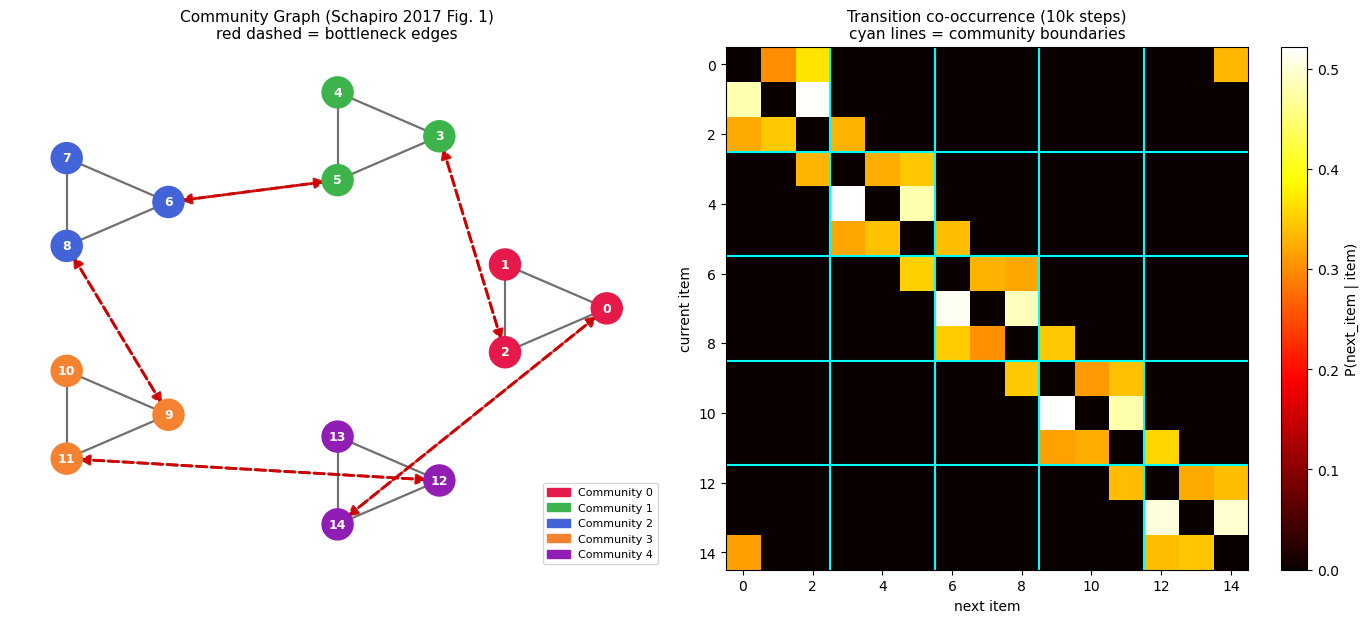

Within-community cells (bright) cluster along the diagonal — the signal MSP learns.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

COMMUNITY_COLORS = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']

# ── Build NetworkX graph from transition matrix ──────────────────────────────
G = nx.DiGraph()
G.add_nodes_from(range(N_ITEMS))
for i in range(N_ITEMS):
    for j in range(N_ITEMS):
        if env._transition_matrix[i, j] > 0:
            G.add_edge(i, j)

# ── Layout ───────────────────────────────────────────────────────────────────
# Communities sit on a ring (radius 2.5).
# Within each community (ipc=3):
#   k=0 (first, receives ring edge from c-1) → points toward community c-1
#   k=1 (middle, non-bottleneck)            → points outward (away from center)
#   k=2 (last, sends ring edge to c+1)      → points toward community c+1
# So bottleneck nodes naturally face their ring neighbor.
ipc  = env.items_per_community
pos  = {}
ring_r   = 2.5   # distance between community centers
local_r  = 0.75  # radius of intra-community triangle

for c in range(N_COMMUNITIES):
    theta_c = 2 * np.pi * c / N_COMMUNITIES
    cx = np.cos(theta_c) * ring_r
    cy = np.sin(theta_c) * ring_r
    step = 2 * np.pi / N_COMMUNITIES          # angular gap between communities
    # offsets from community center direction (theta_c):
    #   k=0 → back toward c-1 (-step), k=1 → outward (+π), k=2 → forward toward c+1 (+step)
    angle_offsets = [-step, np.pi, step]
    for k in range(ipc):
        node = c * ipc + k
        ang  = theta_c + angle_offsets[k]
        pos[node] = (cx + np.cos(ang) * local_r, cy + np.sin(ang) * local_r)

node_colors = [COMMUNITY_COLORS[env.community[n]] for n in range(N_ITEMS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel 1: Graph ────────────────────────────────────────────────────────────
ax = axes[0]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=500)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color='white', font_weight='bold')
within_edges  = [(u, v) for u, v in G.edges() if env.community[u] == env.community[v]]
between_edges = [(u, v) for u, v in G.edges() if env.community[u] != env.community[v]]
nx.draw_networkx_edges(G, pos, edgelist=within_edges,  ax=ax,
                       edge_color='#555555', arrows=False, width=1.5, alpha=0.6)
nx.draw_networkx_edges(G, pos, edgelist=between_edges, ax=ax,
                       edge_color='#cc0000', arrows=False, width=2.0, alpha=0.9,
                       style='dashed')
legend_patches = [mpatches.Patch(color=COMMUNITY_COLORS[c], label=f'Community {c}')
                  for c in range(N_COMMUNITIES)]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)
ax.set_title('Community Graph (Schapiro 2017 Fig. 1)\n'
             'red dashed = bottleneck edges  |  node label = item index', fontsize=10)
ax.axis('off')

# ── Panel 2: Co-occurrence heatmap ────────────────────────────────────────────
ax2 = axes[1]
im = ax2.imshow(co_occur_norm, cmap='hot', vmin=0, vmax=co_occur_norm.max())
plt.colorbar(im, ax=ax2, label='P(next_item | item)')
for c in range(1, N_COMMUNITIES):
    ax2.axhline(c * ipc - 0.5, color='cyan', linewidth=1.5)
    ax2.axvline(c * ipc - 0.5, color='cyan', linewidth=1.5)
ax2.set_title('Transition co-occurrence (10 k steps)\ncyan lines = community boundaries', fontsize=10)
ax2.set_xlabel('next item')
ax2.set_ylabel('current item')

plt.tight_layout()
plt.show()

print("Within-community cells (bright) cluster along the diagonal — the signal MSP learns.")